# Installs if needed

In [1]:
# !pip install glob
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
!pip install fastparquet
# !pip install sklearn

In [2]:
# imports
import pandas as pd
import numpy as np
import glob
import pyarrow

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Data Engineering Pipeline 
### 3. Extract, Transform, Load (ETL)
---
Extracting data from all the files. Combine everything into one dataframe.

All the dataframes that were created from the CSV, JSON, and Parquet files. They will now be combined and be ready to be cleaned.

In [3]:
# Load all CSV Files
csv_files = glob.glob('final_project_data_sp2026_L/*.csv')
df_csv = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Load all JSON Files
json_files = glob.glob('final_project_data_sp2026_L/*.json')
df_json = pd.concat((pd.read_json(f, lines=True, orient='records') for f in json_files), ignore_index=True)

# Load Parquet Files
parquet_files = glob.glob('final_project_data_sp2026_L/*.parquet')
df_parquet = pd.concat((pd.read_parquet(f, engine='fastparquet') for f in parquet_files), ignore_index=True)

# check all dataframe shapes
print("CSV DataFrame:")
print(df_csv.shape)

print("\nJSON DataFrame:")
print(df_json.shape)

print("\nParquet DataFrame:")
print(df_parquet.shape)    


CSV DataFrame:
(4004, 79)

JSON DataFrame:
(27805, 79)

Parquet DataFrame:
(31320, 79)


In [4]:
"""
Combine all the data into a single DataFrame for analysis and modeling. This will allow us to clean up the data. 
"""
total_df = pd.concat([df_csv, df_json, df_parquet], ignore_index=True)

# check the combined dataframe
print("\nCombined DataFrame:")
print(total_df.shape[0], "rows,", total_df.shape[1], "columns")



Combined DataFrame:
63129 rows, 79 columns


### 4. Data Transformation 
---
...

In [5]:
"""
Remove all the duplicates that are in the combined dataframe. 
"""

print("\nBefore duplicate removal:", total_df.shape)
total_df = total_df.drop_duplicates()
print("After duplicate removal:", total_df.shape)



Before duplicate removal: (63129, 79)
After duplicate removal: (49366, 79)


In [6]:
"""
Handle all the missing values in the combined dataframe. 
"""
# Check for missing values
print("\nMissing values in each column:", total_df.isnull().sum().sort_values(ascending=False))

# fill in the numerical  columns with median values
num_cols = total_df.select_dtypes(include=[np.number]).columns
total_df[num_cols] = total_df[num_cols].fillna(total_df[num_cols].median())

# fill categorical columns with mode values
cat_cols = total_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    total_df[col] = total_df[col].fillna(total_df[col].mode()[0])


Missing values in each column: Flow Bytes/s            4
 Flow Packets/s         2
 Destination Port       0
 Average Packet Size    0
 Fwd Avg Bulk Rate      0
                       ..
 Bwd IAT Std            0
 Bwd IAT Mean           0
Bwd IAT Total           0
 Fwd IAT Min            0
 Label                  0
Length: 79, dtype: int64


In [7]:
"""
Remove outliers from the combined dataframe using IQR method
"""
'''def iqr_outlier_removal(df, column):
    for col in column: 
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

total_df = iqr_outlier_removal(total_df, num_cols)
print(total_df.shape)

print(total_df[total_df.columns[-1]].astype(str).str.strip().value_counts())'''

'def iqr_outlier_removal(df, column):\n    for col in column: \n        Q1 = df[col].quantile(0.25)\n        Q3 = df[col].quantile(0.75)\n        IQR = Q3 - Q1\n        lower_bound = Q1 - 1.5 * IQR\n        upper_bound = Q3 + 1.5 * IQR\n        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]\n    return df\n\ntotal_df = iqr_outlier_removal(total_df, num_cols)\nprint(total_df.shape)\n\nprint(total_df[total_df.columns[-1]].astype(str).str.strip().value_counts())'

# 5. Data Storage 
We used a SQLite DB to store all the data

In [8]:
import sqlite3

sqlconnection = sqlite3.connect('final_project_data.db')

total_df.to_sql('final_project_data', sqlconnection, if_exists='replace', index=False)

query = 'SELECT COUNT(*) FROM final_project_data'

sqlconnection.close()


# 6. Reading Data

Reading data from the SQLite3 Database.

In [9]:
# connect to database
sqlconnection = sqlite3.connect('final_project_data.db')

# read the table into a pandas dataframe
final_df = pd.read_sql_query('SELECT * FROM final_project_data', sqlconnection)

# check if the dataframe is good
print('Loaded df shape:', final_df.shape)
print(final_df.head())

# close the connection 
sqlconnection.close()

Loaded df shape: (49366, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              55109              17                   1   
1                 53       113594958                   4   
2                 53           30485                   1   
3                 53           30445                   1   
4                 53           70860                   1   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        4                          152   
2                        1                           81   
3                        1                           53   
4                        1                           56   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           362                      45   
2                           209                      81   
3                  

# 7. Exploratory Data Analysis
### 8 Step Process
Exploratory data analysis (EDA) is essential for understanding the dataset and making informed decisions about model selection and feature engineering. EDA may include the following: 

---
1. Identifying the shape of the dataset
2. Unify the columns/features names
3. Identifiying the unique values in the class variable 
4. Identifying if the dataset has missing data
5. Identifiying columns with a high percentage of missing data
6. Performing univariate analysis
    - stats of columns: mean, SD, or variance
    - identify columns with low or near-zero variance. These features/columns 
    contain little information and may be removed during feature engineering.
    - Visualization: bar plots, pie charts, boxplots, or violin plots
7. Performing bivariate analysis
    - generating pari plots of each pair of columns 
    - computing and visualizing the correlation matrix of the dataset columns or partial subset of them
8. Idenfity Outliers
    - Identify outliers using interquartile ratio (IQR): IQR = Q3 – Q1, with data with values less than $(Q1 – 1.5*IQR)$ and larger than $(Q3 + 1.5*IQR)$ are considered outliers.
    - Identifying outliers using histograms or boxplots 

In [10]:
# 1. Identifying the shapte of the dataset. Check the shape and columns and the information about the dataset.
print("\nDataset Shape:", final_df.shape)
print("\nDataset Columns:", final_df.columns)
print("\nDataset Info:", final_df.info())


Dataset Shape: (49366, 79)

Dataset Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Pa

In [11]:
# 2. Unify the columns/features names. Clean column names.
final_df.columns = final_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [12]:
# 3. Identifiying the unique values in the class label variable. Find the unique values in the target variable. 


In [13]:
# 4. Identifying if the dataset has missing data. Check for missing values in the dataset and handle them appropriately (e.g., imputation, removal). 
print(final_df.isnull().sum())

destination_port               0
flow_duration                  0
total_fwd_packets              0
total_backward_packets         0
total_length_of_fwd_packets    0
                              ..
idle_mean                      0
idle_std                       0
idle_max                       0
idle_min                       0
label                          0
Length: 79, dtype: int64


In [14]:
# 5. Univariate analysis

# 8. Data Preprocessing

## 8.1 Context and Technology Choice
Techniques include (in this order; refer to data leakage slides for details):
• Duplicate removal
• Splitting the dataset into train and test splits (and a validation split, if needed)
• Handling missing data using data deletion or imputation. Ensure that test statistics
are never used for data imputation.
• Encoding categorical data using label encoding or one-hot encoding.
• Add any other techniques you find needed.
## 8.2 Justifications
Justify your choices in .1.
## 8.3 Status
State the status of this decision, as well as names and dates. The status could be proposed,
accepted, or rejected.

In [15]:
#8.1 Techniques

#Duplicate Removal was handled in earlier steps


print("Class distribution before relabeling:")
print(final_df["label"].value_counts())

#Stripping Whitespace from column names, they were already cleaned for the most part in earlier steps

final_df["label"] = final_df["label"].astype(str).str.strip()

#Removing Heartbleed rows as outlined in project template
final_df = final_df[final_df["label"] != "Heartbleed"].copy()

#Group DOS variants into larger attack class so we can have two groups for our binary issue (attack vs benign)

dos_labels = {"DoS GoldenEye", "DoS Hulk", "DoS Slowhttptest",
              "DoS Slowloris", "DoS slowloris"}
final_df["label"] = np.where(final_df["label"].isin(dos_labels), "attack", final_df["label"])

print("\n[R8-E] Class distribution after relabeling (binary):")
print(final_df["label"].value_counts())

Class distribution before relabeling:
label
DoS Hulk            22928
DoS GoldenEye       16250
DoS Slowhttptest     5228
BENIGN               4949
Heartbleed             11
Name: count, dtype: int64

[R8-E] Class distribution after relabeling (binary):
label
attack    44406
BENIGN     4949
Name: count, dtype: int64


In [16]:
#Encoding

#Initializing x (set of features) as everything but our last column (label/response column)

x = final_df.drop(columns = ["label"])

#Making y our response variable (label column), reshaping for our ordinal encoder

y = final_df["label"].to_numpy().reshape(-1,1) 

#Calling our encoder
enc = OrdinalEncoder()
y_encoded = enc.fit_transform(y).flatten()


#Making 0-1 indicator by name for attack and benign, benign = 0, attack = 1
benign_int = enc.transform(np.array([["BENIGN"]]))[0,0]

y = np.where(y_encoded == benign_int, 0, 1).astype(int)

unique, counts = np.unique(y, return_counts=True)

In [17]:
#Train and Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size = 0.2,
    stratify = y,
    random_state = 1)

print(f"Train shape: {x_train.shape}")
print(f"Test shape:  {x_test.shape}")

Train shape: (39484, 78)
Test shape:  (9871, 78)


In [18]:
#Encoding

numeric_features = x_train.select_dtypes(include = [np.number]).columns.tolist()

#Finding median numeric values from train set (only train set, have to keep test set separate) and filling missing values in our train and test sets with these median values
train_medians = x_train[numeric_features].median()
x_train[numeric_features] = x_train[numeric_features].fillna(train_medians)
x_test[numeric_features] = x_test[numeric_features].fillna(train_medians)


print(f"       NaNs remaining in x_train: {x_train.isnull().sum().sum()}")
print(f"       NaNs remaining in x_test:  {x_test.isnull().sum().sum()}")
print(f"       x_train shape: {x_train.shape}")
print(f"       x_test shape:  {x_test.shape}")
    

       NaNs remaining in x_train: 0
       NaNs remaining in x_test:  0
       x_train shape: (39484, 78)
       x_test shape:  (9871, 78)


# 9. Feature Engineering

## 9.1 Context and Technology Choice
Feature engineering consists of selecting, creating, or transforming features to improve
model performance or reduce computational costs. Techniques include:
Feature Scaling
Techniques may include:
• Scaling into a specific range, for instance, [0, 1]
• Normalization (feature std is scaled to 1) or standardization (feature mean=0 and
std=1)
Feature Selection
Techniques may include:
• Remove features with near-zero variance.
• Remove one feature from each pair of correlated features.
• Perform forward, backward, and recursive feature selection.
• Filter-based methods.
• Perform LASSO feature selection.
• Perform feature selection using feature importance in tree-based
classifiers/regressors (XGBoost or Random Forest).
Feature extraction
Techniques may include:
• Principal component analysis (PCA)
• Linear discriminant analysis (LDA)

In [19]:
#Initializing Standard Scaler

x_train = x_train.replace([np.inf, -np.inf], np.nan).fillna(x_train.median())
x_test  = x_test.replace([np.inf, -np.inf], np.nan).fillna(x_train.median())


scaler = StandardScaler()

x_train_standard = scaler.fit_transform(x_train)
x_test_standard  = scaler.fit_transform(x_test)

print(x_train_standard.shape)
print(x_test_standard.shape)

(39484, 78)
(9871, 78)


In [20]:
#Correlation and Feature Selection

x_train_df = pd.DataFrame(x_train_standard)
corr_matrix = x_train_df.corr().abs()

#Checking for low-variance features that could potentially be dropped due to multicollinearity

low_var = (x_train_df.var() < .01).sum()
print(f"Features with variance < 0.01: {low_var}")


#Checking for highly correlated feature pairs using upper triangle of correlation matirx
n_features = corr_matrix.shape[0]

high_corr_pairs = 0
for i in range(n_features):
    for j in range(i + 1, n_features):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs += 1

print(f"Feature pairs with |r| > 0.95:  {high_corr_pairs}")
print(f"\nTotal feature count: {x_train_standard.shape[1]}")


#Dropping Correlated Features
to_drop = set()
for i in range(n_features):
    for j in range(i + 1, n_features):
        if corr_matrix.iloc[i, j] > 0.95:
            to_drop.add(j)  

keep_idx = [i for i in range(n_features) if i not in to_drop]
print(f"[R9-F2] Dropped {len(to_drop)} features")
print(f"        Kept {len(keep_idx)} of {n_features} features")

x_train_pruned = x_train_standard[:, keep_idx]
x_test_pruned  = x_test_standard[:,  keep_idx]

print(f"\n        x_train_pruned shape: {x_train_pruned.shape}")
print(f"        x_test_pruned shape:  {x_test_pruned.shape}")

Features with variance < 0.01: 10
Feature pairs with |r| > 0.95:  83

Total feature count: 78
[R9-F2] Dropped 30 features
        Kept 48 of 78 features

        x_train_pruned shape: (39484, 48)
        x_test_pruned shape:  (9871, 48)


# 10. Processed Data Loading
## 10.1 Context and Technology Choice
Load the cleaned data in step 9 into a storage medium (a file or a database).

In [21]:
#Loading cleaned data into database
kept_columns = [f"f{i}" for i in keep_idx]

train_out = pd.DataFrame(x_train_pruned, columns=kept_columns)
train_out["target"] = y_train

test_out = pd.DataFrame(x_test_pruned, columns=kept_columns)
test_out["target"] = y_test

# Write to SQLite — same pattern as §5 cell 12
sqlconnection = sqlite3.connect('processed_data.db')

train_out.to_sql('train_processed', sqlconnection, if_exists='replace', index=False)
test_out.to_sql('test_processed',   sqlconnection, if_exists='replace', index=False)

sqlconnection.close()

print(f"[R10-A] Wrote train_processed ({train_out.shape}) and test_processed ({test_out.shape}) to processed_data.db")\


#Reloading cleaned data from database
sqlconnection = sqlite3.connect('processed_data.db')

loaded_train = pd.read_sql_query('SELECT * FROM train_processed', sqlconnection)
loaded_test  = pd.read_sql_query('SELECT * FROM test_processed',  sqlconnection)

sqlconnection.close()

# Verify the load
print(f"Loaded train: {loaded_train.shape}")
print(f"Loaded test:  {loaded_test.shape}")
print()
print("[SUB-4] First 20 rows of the loaded processed training data:")
loaded_train.head(20)

[R10-A] Wrote train_processed ((39484, 49)) and test_processed ((9871, 49)) to processed_data.db
Loaded train: (39484, 49)
Loaded test:  (9871, 49)

[SUB-4] First 20 rows of the loaded processed training data:


,f0,f1,f2,f4,f6,f7,f8,f9,f10,f11,...,f58,f59,f60,f61,f67,f69,f70,f71,f75,target
0,-0.138413,-1.165635,-0.040199,-0.189599,-0.979088,-0.007776,-0.596512,-1.003749,-1.211884,-0.183184,...,0.0,0.0,0.0,0.0,-0.155873,-1.518950,-0.298296,-0.087266,-0.209168,0
1,-0.138413,-0.888048,0.005192,-0.035732,0.265968,-0.106058,-0.180119,0.113668,0.591668,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,-0.297755,-0.087266,-0.209168,1
2,-0.138413,1.172039,-0.009939,-0.029249,0.317559,-0.106058,0.005523,0.339126,0.576844,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,-0.298065,-0.087266,-0.209168,1
3,-0.138413,0.832164,0.005192,0.078372,0.076802,-0.106058,0.163405,0.236784,0.576844,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,-1.518950,-0.297755,-0.087266,-0.209168,1
4,-0.138413,-0.900108,0.027887,0.469090,0.320999,-0.106058,0.794619,0.660148,0.576844,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,0.180776,-0.087266,-0.209168,1
5,-0.138413,-1.048880,0.005192,-0.027520,0.331317,-0.106058,-0.155396,0.171361,1.933214,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,-0.298296,-0.087266,-0.209168,1
6,-0.085106,-1.032362,0.020322,-0.040054,-0.308408,-0.106058,-0.286299,-0.400373,-0.764702,-0.183184,...,0.0,0.0,0.0,0.0,0.088517,0.482949,-0.084453,-0.087266,-0.209168,0
7,-0.138413,0.427964,0.005192,-0.040054,0.231575,-0.106058,-0.193131,0.083303,1.471208,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,-0.297725,-0.087266,-0.209168,1
8,-0.138413,1.394738,-0.025069,-0.037893,0.207499,-0.106058,0.285720,0.487131,-1.211884,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,-0.295233,-0.087266,-0.209168,1
9,-0.138413,0.164375,0.020322,-0.063393,0.045848,-0.106058,-0.342512,-0.178118,0.129662,-0.183184,...,0.0,0.0,0.0,0.0,-0.094515,0.482949,-0.298296,-0.087266,1.646741,1


# 11. Model Selection and Training
Train and compare five classification models: Logistic Regression, Decision Tree, Random Forest, KNN, and XGBoost. These models were selected because they represent different approaches to classification: linear models, tree-based models, ensemble models, and distance-based models.


In [22]:
# Logistic Regression

log_clf = LogisticRegression(max_iter=1000, random_state=1)

log_clf.fit(x_train_pruned, y_train)

y_pred = log_clf.predict(x_test_pruned)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.983790902644109
Precision: 0.9876971256011632
Recall: 0.994370003377998
F1 Score: 0.9910223319492761


The logistic regression model achieved very good performace, with very high accuracy, precision, recall, and F1-score, indicating that the selected features are highly effective for distinguishing benign traffic from attacks.

In [23]:
# Decision Tree

dt_clf = DecisionTreeClassifier(random_state=1)

dt_clf.fit(x_train_pruned, y_train)

y_pred = dt_clf.predict(x_test_pruned)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.10971532772768716
Precision: 0.7687861271676301
Recall: 0.014975791014525392
F1 Score: 0.029379279876297768


The Decision Tree model performed poorly , with very low accuracy, recall, and F1-score. Although precision is relatively high, the model fails to correctly identify most attack instances.

In [24]:
# Random Forest

rf_clf = RandomForestClassifier(n_estimators=100, random_state=1)

rf_clf.fit(x_train_pruned, y_train)

y_pred = rf_clf.predict(x_test_pruned)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8412521527707426
Precision: 0.9998633132859486
Recall: 0.8236685057988965
F1 Score: 0.9032536889547447


The Random Forest model performed well, with high precision, recall, and F1-score. It identified attack traffic effectively while producing very few false positives.

In [25]:
# KNN

knn_clf = KNeighborsClassifier(n_neighbors=5)

knn_clf.fit(x_train_pruned, y_train)

y_pred = knn_clf.predict(x_test_pruned)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.997467328538142
Precision: 0.9988733663812528
Recall: 0.9983110010133994
F1 Score: 0.9985921045221603


The KNN model achieved outstanding performance, with extremely high accuracy, precision, recall, and F1-score. It was highly effective at correctly classifying both benign and attack traffic.

In [26]:
# XGBoost

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=150,
    random_state=1,
    eval_metric='logloss'
)

xgb_clf.fit(x_train_pruned, y_train)

y_pred = xgb_clf.predict(x_test_pruned)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.13494073548779253
Precision: 1.0
Recall: 0.03850917689449386
F1 Score: 0.07416242003686437


The XGBoost model performed poorly, with very low accuracy, recall, and F1-score. Although precision is perfect, the model correctly identified only a small portion of attack traffic.

## Model Performance Summary

After evaluating all five classifiers, KNN achieved the best overall performance, followed by Logistic Regression and Random Forest. Decision Tree and XGBoost performed poorly on this dataset.

KNN produced the highest accuracy and F1-score, indicating the strongest balance between precision and recall. Logistic Regression also performed extremely well and offers the advantage of being simpler and more interpretable. Random Forest showed strong results, especially in precision.

Based on these results, KNN is selected as the best-performing classifier for this project.

# 12. Model Evaluation

The selected model is evaluated using the test dataset, which was not used during training. This provides a realistic measure of how well the classifier generalizes to unseen data.

For classification tasks, the chosen evaluation metrics are accuracy, precision, recall, F1-score, confusion matrix, and AUC. These metrics provide a complete view of model performance, especially in cybersecurity problems where detecting attacks is critical.

In [27]:
#Metrics for KNN

y_pred = knn_clf.predict(x_test_pruned)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.997467328538142
Precision: 0.9988733663812528
Recall: 0.9983110010133994
F1 Score: 0.9985921045221603


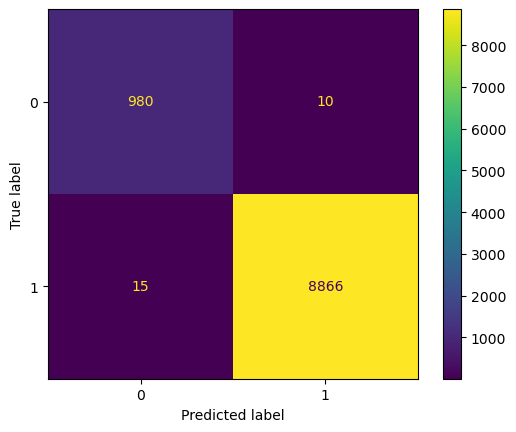

In [28]:
##Confusion Matrix for KNN

ConfusionMatrixDisplay.from_estimator(knn_clf, x_test_pruned, y_test)
plt.show()

In [29]:
#AUC for KNN
y_prob = knn_clf.predict_proba(x_test_pruned)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.9988304392875951


The KNN classifier achieved outstanding performance on the test dataset. All evaluation metrics are near 1.0, indicating excellent predictive ability. 

The confusion matrix shows only a small number of misclassifications, and the very high AUC confirms that the model effectively distinguishes benign traffic from attack traffic.

# 13. Model Deployment and Monitoring

The best-performing model can be deployed through a web application so users can enter new customer information and receive real time predictions. Based on Chapter 9 of the course textbook, a practical choice is to use the Flask framework, which allows machine learning models to be integrated into lightweight Python web applications.

The trained model should be saved after training and loaded by the application when needed, avoiding the need to retrain it each time the system starts.

After deployment, the model should be monitored regularly by tracking prediction accuracy, response time, and changes in incoming data. If performance decreases over time due to data drift or changing customer behavior, the model should be retrained using updated data.